# In-Class Assignment 8

## Exploring Heat Transfer via Convection with MESA

### Learning Objectives

- identify convective and radiative regions using MESA models and analytical expressions
- explain convective behavior in advanced burning massive stars and Solar-like stars

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## a. Convection in Massive Stars

Download the following model files locally. These data were produced using the MESA [`20m_ms_convection_profile.data`](https://docs.mesastar.org/en/latest/test_suite/20M_pre_ms_to_core_collapse.html) test suite. 

* **New** $20.0 M_{\odot}$ Main-Sequence _profile_ data: [20m_ms_convection_profile.data](data/20m_ms_convection_profile.data);

1. Plot the adiabatic gradient `grada`, the radiative gradient `gradr`, and the _Ledoux_ term (`gradL`) as a function of radius (in units of Rsun) using the MESA data.

> Hint: You may want to set your ylim to `0.2,1`

2. Locate the approximate fractional radius and annotate where the Schwarzchild Criterion
$$
\nabla < \nabla_{\rm{ad}}
$$ 
is volated and fill in the convective region of the star using [`plt.fill_betweenx()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_betweenx.html).

> Hint: You may want to set your yrange to `(0,1)`


3. We found that the limiting cases for $\nabla_{\rm{ad}}$ is: 0.4 for an ideal gas without radiation and 0.25 for a radiation-dominated gas. Label these two limits on the same plot using `plt.axhline`
    

4. **Describe** in a few sentences where is the model convective and way? Also, describe where $\nabla_{\rm{ad}}$ is closer to one limit or the other and why? What does it mean when $\nabla_{\rm{L}}=0$?



> Hint: Compare with Pols Fig. 5.4. 


In [2]:
## load MESA data here
massive_star_ms_profile = pd.read_csv('data/20m_ms_convection_profile.data',sep=r'\s+',header=4)
list(massive_star_ms_profile)

['zone',
 'mass',
 'logR',
 'logT',
 'logRho',
 'logP',
 'x_mass_fraction_H',
 'y_mass_fraction_He',
 'z_mass_fraction_metals',
 'logdq',
 'dq_ratio',
 'q',
 'radius',
 'radius_cm',
 'velocity',
 'v_div_r',
 'pressure_scale_height',
 'mass_grams',
 'mmid',
 'logxq',
 'acoustic_radius',
 'acoustic_r_div_R_phot',
 'temperature',
 'entropy',
 'logS',
 'logS_per_baryon',
 'pressure',
 'prad',
 'pgas',
 'logPgas',
 'pgas_div_ptotal',
 'eta',
 'mu',
 'grada',
 'cv',
 'cp',
 'gamma1',
 'free_e',
 'chiRho',
 'chiT',
 'csound',
 'v_div_csound',
 'eos_phase',
 'eos_frac_OPAL_SCVH',
 'eos_frac_HELM',
 'eos_frac_Skye',
 'eos_frac_PC',
 'eos_frac_FreeEOS',
 'eos_frac_CMS',
 'eos_frac_ideal',
 'pgas_div_p',
 'prad_div_pgas',
 'prad_div_pgas_div_L_div_Ledd',
 'pressure_scale_height_cm',
 'eps_grav',
 'eps_nuc',
 'non_nuc_neu',
 'pp',
 'cno',
 'tri_alpha',
 'c_alpha',
 'n_alpha',
 'o_alpha',
 'ne_alpha',
 'na_alpha',
 'mg_alpha',
 'si_alpha',
 's_alpha',
 'ar_alpha',
 'ca_alpha',
 'ti_alpha',
 'cr_alp

In [3]:
rsun_cgs = 6.96e10  # cm

In [4]:
# example reading a variable from the profile data
massive_star_ms_profile_gradrad = massive_star_ms_profile['gradr']
massive_star_ms_profile_radius_cm = massive_star_ms_profile['radius_cm']
massive_star_ms_profile_gradad = massive_star_ms_profile['grada']
massive_star_ms_profile_gradL = massive_star_ms_profile['gradL']

Text(0, 0.5, '$\\nabla$')

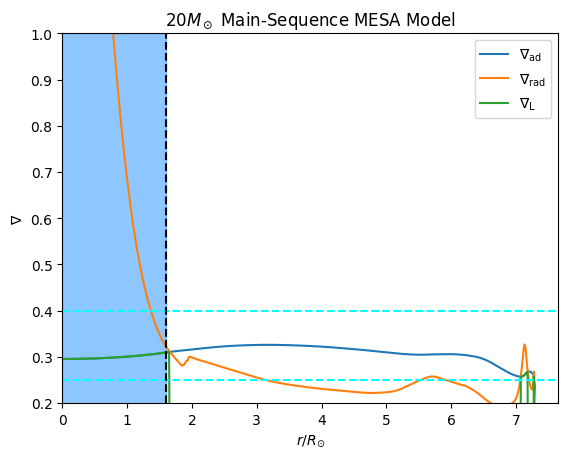

In [5]:
## 1-3 result here
plt.title('20$M_\odot$ Main-Sequence MESA Model')

plt.plot(massive_star_ms_profile_radius_cm/rsun_cgs,
         massive_star_ms_profile_gradad,label=r'$\nabla_{\rm{ad}}$')

plt.plot(massive_star_ms_profile_radius_cm/rsun_cgs,
         massive_star_ms_profile_gradrad,label=r'$\nabla_{\rm{rad}}$')

plt.plot(massive_star_ms_profile_radius_cm/rsun_cgs,
         massive_star_ms_profile_gradL,label=r'$\nabla_{\rm{L}}$')


plt.axhline(0.40,ls='--',color='cyan')
plt.axhline(0.25,ls='--',color='cyan')

plt.fill_betweenx((0,1),0,1.6,color='dodgerblue',alpha=0.5)

plt.axvline(1.6,color='k',ls='--')

plt.ylim(0.2,1)
plt.xlim(0,)

plt.legend()
plt.xlabel(r'$r/R_{\odot}$')
plt.ylabel(r'$\nabla$')

### 4. result here
Radiation dominated, lower $\nabla_{\rm{ad}}$ in the atmosphere and it is in fact convective. When $\nabla_{\rm{L}}=0$, the composition is uniform.

## b. Convection in a Solar-Like Star

Download the following model files locally. These data were produced using the MESA [`1m_pre_ms_to_wd.data`](https://docs.mesastar.org/en/latest/test_suite/1m_pre_ms_to_wd.html) test suite. 

* $1.0 M_{\odot}$ Main-Sequence _profile_ data: [1m_pre_ms_to_wd.data](data/1m_pre_ms_to_wd.data);

1. Plot the adiabatic gradient `grada` and the radiative gradient `gradr` as a function of radius (in units of Rsun) using the MESA data.

2. Locate the approximate fractional radius and annotate where the Schwarzchild Criterion
$$
\nabla < \nabla_{\rm{ad}}
$$ 
is volated and fill in the convective region of the star using [`plt.fill_betweenx()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_betweenx.html).

> Hint: You may want to set your yrange to `(0,1)`


3. We found that the limiting cases for $\nabla_{\rm{ad}}$ is: 0.4 for an ideal gas without radiation and 0.25 for a radiation-dominated gas. Label these two limits on the same plot using `plt.axhline`
    

4. **Describe** in a few sentences where is the model convective and way? Also, describe where $\nabla_{\rm{ad}}$ is closer to one limit or the other and why?



> Hint: Compare with Pols Fig. 5.4. 


In [6]:
## load data here
massive_star_ms_profile = pd.read_csv('data/1m_pre_ms_to_wd.data',sep=r'\s+',header=4)
massive_star_ms_profile_gradrad = massive_star_ms_profile['gradr']
massive_star_ms_profile_radius_cm = massive_star_ms_profile['radius_cm']
massive_star_ms_profile_gradad = massive_star_ms_profile['grada']

Text(0, 0.5, '$\\nabla$')

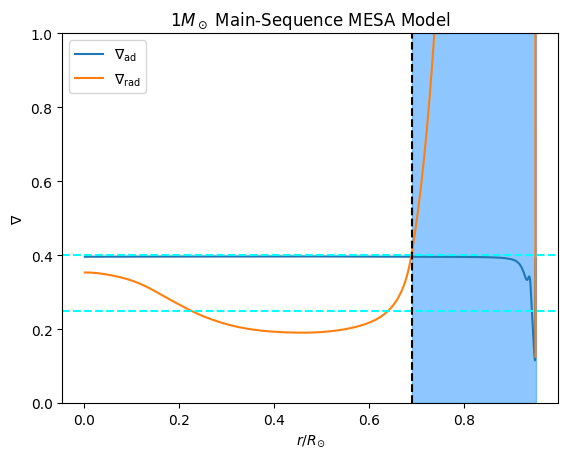

In [7]:
## 1-3 result here
plt.plot(massive_star_ms_profile_radius_cm/rsun_cgs,
         massive_star_ms_profile_gradad,label=r'$\nabla_{\rm{ad}}$')

plt.plot(massive_star_ms_profile_radius_cm/rsun_cgs,
         massive_star_ms_profile_gradrad,label=r'$\nabla_{\rm{rad}}$')

plt.title('1$M_\odot$ Main-Sequence MESA Model')

plt.axhline(0.40,ls='--',color='cyan')
plt.axhline(0.25,ls='--',color='cyan')

plt.fill_betweenx((0,1),0.69,0.95,color='dodgerblue',alpha=0.5)

plt.axvline(0.69,color='k',ls='--')

plt.ylim(0,1)

plt.legend()
plt.xlabel(r'$r/R_{\odot}$')
plt.ylabel(r'$\nabla$')

## c. Convection in an Advanced Massive Star

Download the following model files locally. These data were produced using the MESA [`15m_core_O_burning_profile.data`](https://docs.mesastar.org/en/latest/test_suite/1m_pre_ms_to_wd.html) test suite. 

* **New** $15 M_{\odot}$ Core O-Burning _profile_ data: [15m_core_O_burning_profile.data](data/15m_core_O_burning_profile.data);

1. Plot the adiabatic gradient `grada` and the radiative gradient `gradr` as a function of **mass** `mass` (in units of Msun) using the MESA data from 0 to 7 Msun.

2. On the same plot, plot the normalized nuclear energy generation rate `eps_nuc` and the non-normalized mean molecular weight. Set the ylim to 0,2.

3. Locate the approximate fractional radius and annotate where the Schwarzchild Criterion
$$
\nabla < \nabla_{\rm{ad}}
$$ 
is volated and fill in the convective region of the star using [`plt.fill_betweenx()`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.fill_betweenx.html).

> Hint: There are at least two in this model.

> Hint: You may want to set your yrange to `(0,2)`


4. **Describe** in a few sentences where is the model convective and way? Also, describe where $\nabla_{\rm{ad}}$ is closer to one limit or the other and why?


> Hint: Compare with [Farmer et al. 2016](https://content.cld.iop.org/journals/0067-0049/227/2/22/revision1/apjsaa4c33f15_hr.jpg)

Stars might be like onions after all?? Not parfaits..

In [8]:
## load data
massive_star_ms_profile = pd.read_csv('data/15m_core_O_burning_profile.data',sep=r'\s+',header=4)
massive_star_ms_profile_gradrad = massive_star_ms_profile['gradr']
massive_star_ms_profile_mass = massive_star_ms_profile['mass']
massive_star_ms_profile_gradad = massive_star_ms_profile['grada']
massive_star_ms_profile_eps_nuc = massive_star_ms_profile['eps_nuc']
massive_star_ms_profile_mu = massive_star_ms_profile['mu']

Text(0, 0.5, '$\\nabla,\\mu,\\epsilon_{\\rm{nuc,normalized}}$')

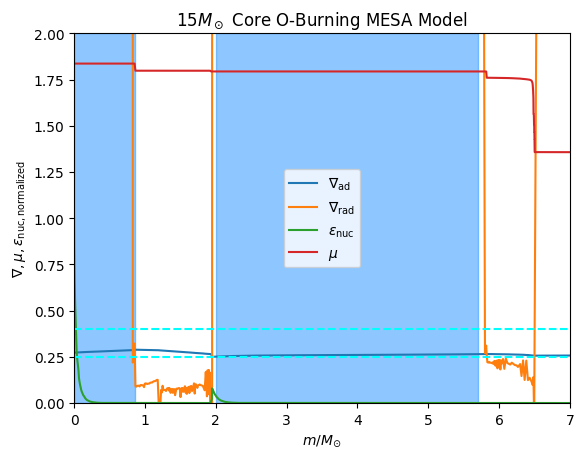

In [9]:
# 1 - 3 result here
plt.plot(massive_star_ms_profile_mass,
         massive_star_ms_profile_gradad,label=r'$\nabla_{\rm{ad}}$')

plt.plot(massive_star_ms_profile_mass,
         massive_star_ms_profile_gradrad,label=r'$\nabla_{\rm{rad}}$')

plt.plot(massive_star_ms_profile_mass,
         massive_star_ms_profile_eps_nuc/max(massive_star_ms_profile_eps_nuc),label=r'$\epsilon_{\rm{nuc}}$')

plt.plot(massive_star_ms_profile_mass,
         massive_star_ms_profile_mu,label=r'$\mu$')

plt.title('15$M_\odot$ Core O-Burning MESA Model')

plt.axhline(0.40,ls='--',color='cyan')
plt.axhline(0.25,ls='--',color='cyan')

plt.xlim(0,7)

plt.fill_betweenx((0,2),0,0.86,color='dodgerblue',alpha=0.5)

plt.fill_betweenx((0,2),2.,5.7,color='dodgerblue',alpha=0.5)

plt.ylim(0,2)

plt.legend()
plt.xlabel(r'$m/M_{\odot}$')
plt.ylabel(r'$\nabla,\mu,\epsilon_{\rm{nuc,normalized}}$')